6で作成したチャープ信号に対してSTFTを施し，
横軸を時間 [s]，縦軸を周波数 [Hz] としてスペクトログラムをプロットしなさい．
ただし，窓は $N = 1024$ 点のハン窓，ホップ長は $H = 512$ 点とする．

In [1]:
from pathlib import Path
import numpy as np
import soundfile as sf

output_dir = Path("outputs/audio")
output_dir.mkdir(parents=True, exist_ok=True)

fs = 16000
T = 5.0
f0 = 100.0
f1 = 4000.0
amplitude = 0.5
k = (f1 - f0) / T

chirp_path = output_dir / "06_chirp_100_to_4000hz.wav"

if chirp_path.exists():
    x, sr = sf.read(chirp_path, dtype="float32")
    fs = sr
else:
    t = np.arange(int(fs * T)) / fs
    x = amplitude * np.sin(2 * np.pi * (f0 * t + 0.5 * k * t**2))
    sf.write(chirp_path, x, fs)

print(f"使用する音声: {chirp_path}")
print(f"fs = {fs} Hz")
print(f"samples = {len(x)}")
print(f"duration = {len(x) / fs:.2f} s")


使用する音声: outputs/audio/06_chirp_100_to_4000hz.wav
fs = 16000 Hz
samples = 80000
duration = 5.00 s


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path

figure_dir = Path("outputs/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

n_fft = 1024
hop_length = 512

D = librosa.stft(
    x.astype(float),
    n_fft=n_fft,
    hop_length=hop_length,
    window="hann",
)

D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

print(f"STFT shape: {D.shape}")
print(f"frequency bins: {D.shape[0]}")
print(f"time frames: {D.shape[1]}")


STFT shape: (513, 157)
frequency bins: 513
time frames: 157


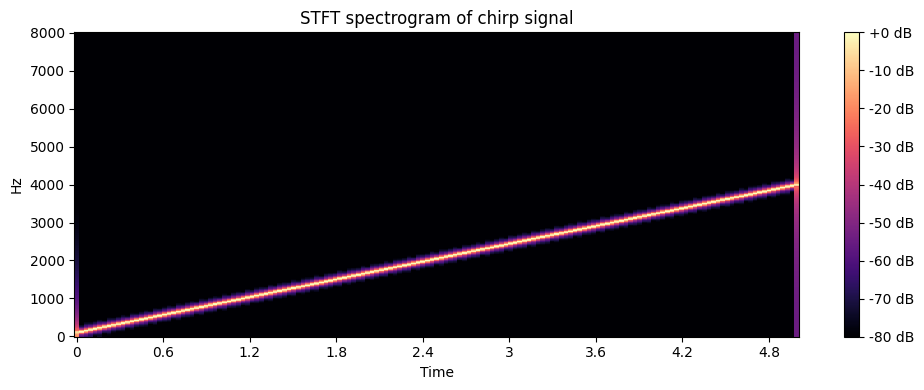

In [5]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    D_db,
    sr=fs,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
)
plt.colorbar(format="%+2.0f dB")
plt.title("STFT spectrogram of chirp signal")
plt.tight_layout()
plt.savefig(figure_dir / "08_chirp_stft_spectrogram.png", dpi=150)
plt.show()


スペクトログラムでは，時間が進むにつれて周波数が上昇する斜めの帯として見える．
これはチャープ信号の瞬時周波数が $100\,\mathrm{Hz}$ から $4000\,\mathrm{Hz}$ へ増加するため．
